In [47]:

import numpy as np 
import h5py as h5 
import camb
from scipy.linalg import eigvals
import matplotlib.pyplot as plt
from velocileptors.LPT.gaussian_streaming_model_fftw import GaussianStreamingModel
from scipy.optimize import minimize

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from colossus.cosmology import cosmology

import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.optimize import least_squares

from compact.streaming import *
from compact.model import *
from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from halotools.mock_observables import tpcf_multipole


from tqdm import tqdm
import emcee

from compact.plot import *

from scipy.interpolate import UnivariateSpline

import warnings
warnings.filterwarnings('ignore')

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20


In [14]:
# cosmo stuff

cosmo = cosmology.setCosmology('planck18')
redshift = 0.100 # z0p100
a = 1 / (1+redshift)
H = cosmo.Hz(redshift) # Hz in physical km/s/Mpc
h = cosmo.h

uc = h/a/H

In [2]:
test_path ='/spiffball/salcedo/AbacusSummit/Snapshots/base_c000/base_c000_ph000/z0p100/halo_base_c000_ph000_z0p100.h5'

mass_col = 'mass'          # placeholder — adjust to actual field name
pos_cols = ['x', 'y', 'z']   # placeholder
vel_cols = ['vx', 'vy', 'vz']  # placeholder
mass_thresh = 1e13

with h5.File(test_path, 'r') as hdf:
    print(hdf['halos'].dtype.names)
    ds = hdf['halos']
    #print(ds.shape)
    #print((ds.fields('mass') > 1e13).sum())
    #print(type(ds.fields('mass')))

    n = ds.shape[0]
    chunk_size = 5_000_000

    pos_list, vel_list, mass_list = [], [], []

    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        chunk = ds[start:stop]          # read full rows for this chunk (fast: contiguous slice)
        mask = chunk[mass_col] > mass_thresh
        if mask.any():
            sel = chunk[mask]
            pos_list.append(np.stack([sel[c] for c in pos_cols], axis=1))
            vel_list.append(np.stack([sel[c] for c in vel_cols], axis=1))
            mass_list.append(sel[mass_col])

    pos = np.concatenate(pos_list)
    vel = np.concatenate(vel_list)
    mass = np.concatenate(mass_list)

print(pos.shape, vel.shape, mass.shape)


('mass', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'r10', 'r25', 'r33', 'r50', 'r67', 'r75', 'r90', 'r95', 'r98', 'r100', 'vrms', 'gid')
(3324928, 3) (3324928, 3) (3324928,)


In [3]:
save_path = '/spiffball/cosweeney/simulations/AbacusSummit/'

with h5.File(save_path+'halo_base_c000_ph000_z0p100_1e13thresh_pos_vel_mass.hdf5', 'w') as hdf:
    hdf.create_dataset(name='pos', data=pos)
    hdf.create_dataset(name='vel', data=vel)
    hdf.create_dataset(name='mass', data=mass)

In [36]:
# load real space cf

save_path = '/spiffball/cosweeney/simulations/AbacusSummit/data/CorrFuncs/xi_hh_pycorr.hdf5'

with h5.File(save_path, 'r') as f:
    xi = f['xi'][()]
    xi_cov = f['xi_cov'][()]
    xi_std = np.sqrt(np.diag(xi_cov))

    rbins = f['s_edges'][()]
    rbins_c = f['s_cens'][()]

In [3]:
# load redshift space cf

save_path = '/spiffball/cosweeney/simulations/AbacusSummit/data/CorrFuncs/RSCFs/xi_smu_hh_pycorr.hdf5'

with h5.File(save_path, 'r') as f:
    s_mu_xi = f['xi_s_mu'][()][:, 120:]

    mu_bins = f['mu_edges'][()]
    
mu_bins_c = 0.5*(mu_bins[1:]+mu_bins[:-1])


In [4]:
from halotools.mock_observables import tpcf_multipole

monopole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, 
    order=0
)
quadrupole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, 
    order=2
)
hexadecapole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, order=4)

Text(0.5, 1.0, 'MDPL2 True Redshift-space $\\xi_{\\rm hh}(s, \\mu)$')

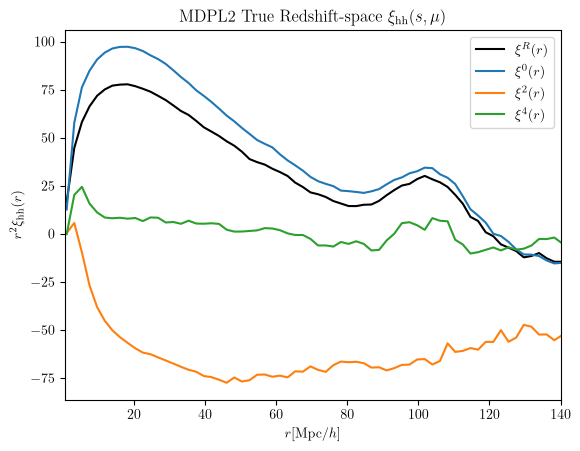

In [5]:
plt.plot(rbins_c, rbins_c**2*xi,
        label=r'$\xi^R(r)$', c='k')

plt.plot(rbins_c, rbins_c**2*monopole,
        label=r'$\xi^0(r)$')
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label=r'$\xi^2(r)$')
plt.plot(rbins_c, rbins_c**2*hexadecapole,
        label=r'$\xi^4(r)$')
plt.legend()
plt.ylabel(r'$r^2\xi_{\rm hh}(r)$')
plt.xlabel(r'$r [\mathrm{Mpc}/h]$')

plt.xlim((0.5, 140))
#plt.ylim((-120,120))
#plt.xscale('log')

plt.title(r'MDPL2 True Redshift-space $\xi_{\rm hh}(s, \mu)$')

In [6]:
# path to AbucusSummit halos
halo_path = '/spiffball/cosweeney/simulations/AbacusSummit/halo_base_c000_ph000_z0p100_1e13thresh_pos_vel_mass.hdf5'

L_box = 2_000 # h^-1 Mpc

with h5.File(halo_path, 'r') as hdf:

    hpos = hdf['pos'][()]

    hvel = hdf['vel'][()]

In [9]:
# test out, benchmark moments function 
import time

frac = 0.01
idx = np.random.choice(len(hpos), int(frac * len(hpos)), replace=False)

t0 = time.perf_counter()
mom_dict = pairwise_velocity_moments(hpos[idx], hvel[idx], rbins, L_box)

t1 = time.perf_counter()

# Rough upper bound: scales as N^2
n_full, n_sub = len(hpos), len(idx)
print(f"Subsample took {t1-t0:.1f}s → full estimate: ~{(t1-t0) * (n_full/n_sub)**2:.0f}s, or {(t1-t0) * (n_full/n_sub)**2 / 3600:.3f} hr") 

Subsample took 0.2s → full estimate: ~1592s, or 0.442 hr


In [10]:
# compute pwv moments

mom_dict = pairwise_velocity_moments(hpos, hvel, rbins, L_box)

In [12]:
# save

save_path = '/spiffball/cosweeney/simulations/AbacusSummit/data/moments/'

with h5.File(save_path+"halo_base_c000_ph000_z0p100_1e13thresh_moments.h5", "w") as f:
    for key, val in mom_dict.items():
        f.create_dataset(key, data=val)
        
    f.attrs["boxsize"] = L_box
    f.attrs["rbins"] = rbins

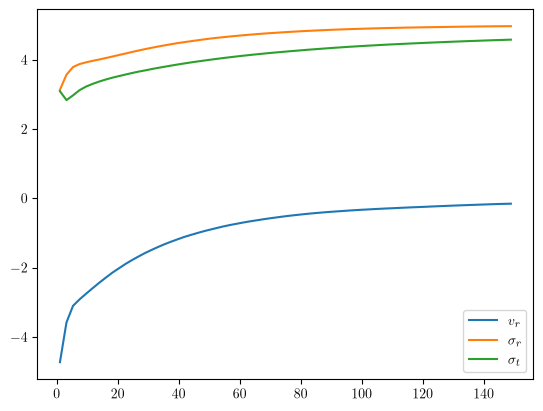

In [15]:
# inspect

rbins_c = 0.5*(rbins[1:]+rbins[:-1])

plt.plot(rbins_c, uc*mom_dict['m10'],label=r'$v_r$') # In km/s
plt.plot(rbins_c, uc*mom_dict['c20'],label=r'$\sigma_r$')
plt.plot(rbins_c, uc*mom_dict['c02'],label=r'$\sigma_t$')

plt.legend()

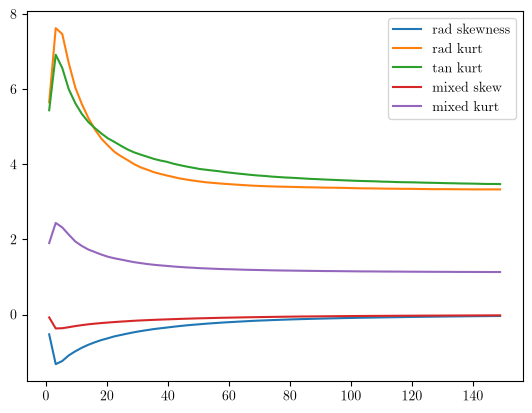

In [16]:
plt.plot(rbins_c, mom_dict['c30'],label=r'rad skewness') # Unitless, higher order moments. 
plt.plot(rbins_c, mom_dict['c40'],label=r'rad kurt')
plt.plot(rbins_c, mom_dict['c04'],label=r'tan kurt')
plt.plot(rbins_c, mom_dict['c12'],label=r'mixed skew')
plt.plot(rbins_c, mom_dict['c22'],label=r'mixed kurt')

plt.legend()

In [17]:
# does GSM look different with these?
from scipy.interpolate import UnivariateSpline


gaussian = moments2gaussian( 
    m_10=UnivariateSpline(rbins_c, uc*mom_dict['m10'], s=0, ext=3),  
    c_20=UnivariateSpline(rbins_c, (uc*mom_dict['c20'])**2, s=0, ext=3), #needs to be the _variance_, NOT dispersion!
    c_02=UnivariateSpline(rbins_c, (uc*mom_dict['c02'])**2, s=0, ext=3)

)

gaussian_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xi,s=0),
    los_pdf_function=gaussian,
    limit=160, 
    #epsilon=1e-16,
    n=300,
)

gaussian_monopole = tpcf_multipole(
    gaussian_s_mu,
    mu_bins, 
    order=0
)
gaussian_quadrupole = tpcf_multipole(
    gaussian_s_mu, 
    mu_bins, 
    order=2
)
gaussian_hexadecapole = tpcf_multipole(
    gaussian_s_mu, 
    mu_bins, 
    order=4
)

In [22]:
mean_vr_interp = UnivariateSpline(rbins_c, mom_dict['m10'][()], s=0, k=5, ext=3)

compact = lambda v, rp, rl: (1/uc)*Pv_compact(v/uc, rp, rl, mean_vr_interp)

compact_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xi,s=0),
    los_pdf_function=compact,
    limit=160, 
    epsilon=0.01,
    n=100,
)

compact_monopole = tpcf_multipole(
    compact_s_mu,
    mu_bins, 
    order=0
)
compact_quadrupole = tpcf_multipole(
    compact_s_mu, 
    mu_bins, 
    order=2
)
compact_hexadecapole = tpcf_multipole(
    compact_s_mu, 
    mu_bins, 
    order=4)

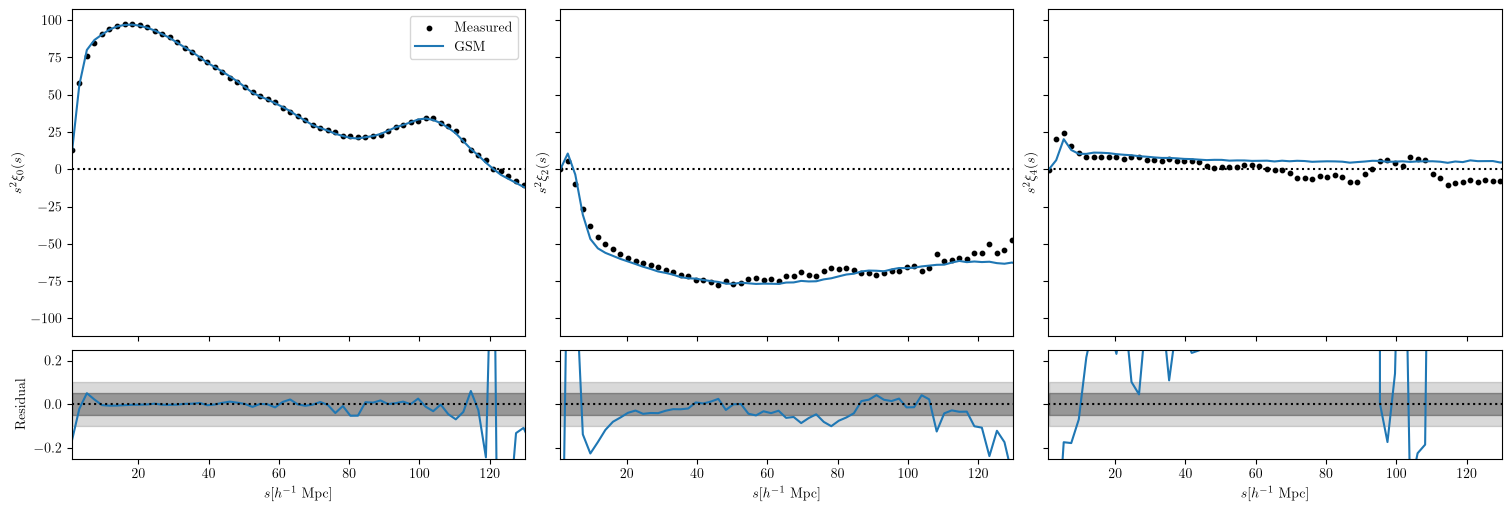

In [21]:
fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole], label='GSM')

for i in range(3):
    axes[0, i].set_xlim((1, 130))

In [31]:
# fit LPT quantities

def joint_fit(r, xihh, v12_sim, sigma2, sigma_v2, x0):
    # Only fit on perturbative scales!
    rmins = np.array([5, 20]) 

    pars_best = np.zeros((len(rmins), 11))  # 9 parameters + softening scale
    
    for idx, rmin in enumerate(rmins):
        mask = ((rmin < r) & (r < 150))
        
        def joint_loss(b):
            pars = b[:-2] # Your 9 parameters
            
            # 1. Evaluate both models using the parameters
            # (Assuming you wrapped the GSM extraction we discussed previously)
            xihh_model = xihh_real(r, pars)
            v12_model  = v12_real(r, pars) # You need a function that returns the v12 model
            
            # 2. Chi-squared for density
            sigma2_soft_xi = sigma2[mask] + b[-2]**2*xihh[mask]**2
            chi2_xi = sum((xihh_model[mask] - xihh[mask])**2/ sigma2_soft_xi )#
            
            # 3. Chi-squared for mean velocity
            sigma2_soft_v = sigma_v2[mask] + b[-1]**2*v12_sim[mask]**2
            chi2_v12 = sum((v12_model[mask] - v12_sim[mask])**2/ sigma2_soft_v )# 
            
            # 4. Total Loss
            # (Note: omitting the log(sigma) term here if errors are fixed, 
            # otherwise keep your softening term for both)
            return chi2_xi + chi2_v12

        # Set alpha_s0 and alpha_s2 to fixed 0 bounds since they only affect dispersion
        bounds = [
            (0.0, 5.0),      # b_1
            (-5.0, 5.0),     # b_2
            (0.0, 0.0), #(-5.0, 5.0),     # b_s
            (0.0, 0.0), #(-5.0, 5.0),     # b_3 (0.0, 0.0), #
            (0.0, 0.0), #(-50.0, 50.0),   # alpha
            (0.0, 0.0), #(-50.0, 50.0),   # alpha_v 
            (0.0, 0.0),      # alpha_s0 (Fixed)
            (0.0, 0.0),      # alpha_s2 (Fixed)
            (0.0, 0.0),     # s2FoG
            (0.0, 1.0),      # eps_soft_xi
            (0.0, 1.0),      # eps_soft_v (new par!)
        ]

        pars_best[idx] = minimize(joint_loss, 
                                  x0=x0, 
                                  bounds=bounds, 
                                  method='nelder-mead', #'nelder-mead', #'L-BFGS-B' 
                                  options={'fatol': 1e-16, 'xatol': 1e-16}, #{'ftol': 1e-8, 'gtol': 1e-8}, #
                                  ).x

    return pars_best


def plot_joint_fits(r, xihh, v12_sim, sigma2, sigma_v2,  pars_best):


    xihh_bests = np.array([xihh_real(r, p[:-2]) for p in pars_best]).T
    v12_bests = np.array([v12_real(r, p[:-2]) for p in pars_best]).T

    fig, axs = plt.subplots(2, 2, figsize=(14, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1],})

    plt.subplot(221)
    plt.scatter(r, r**2*xihh, color = 'k', linewidth = 3, label ='Simulation')
    plt.plot(r, r**2*(xihh + np.sqrt(sigma2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, r**2*(xihh - np.sqrt(sigma2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--', label = '1$\sigma$-Error, JK')

    for idx, rmin in enumerate(rmins) :
        
        style = '-'
        if idx > 0:
            style = '--'

        plt.plot(r, r**2*xihh_bests[:, idx], linewidth = 2, color = 'C' + str(1+idx), label = r'$r_{\rm min}=$' + f'{rmin:.1f}')
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.legend(loc = 'upper left', fontsize = 10, ncol = 2, framealpha = 0.95)
    plt.grid(True)
    #plt.ylim(0, 230)
    plt.ylim(0, max((r**2*xihh)[r > 10])*1.2)
    plt.yticks(fontsize = 20)
    plt.ylabel(r'$r^2\xi_{\rm hh}(r)$ [$h^{-2}$ Mpc$^2$]', fontsize = 20)
    plt.tight_layout()

    ##############################################
    plt.subplot(223)
    plt.plot(r, (xihh + np.sqrt(sigma2))/xihh, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, (xihh - np.sqrt(sigma2))/xihh, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')

    for idx, rmin in enumerate(rmins) :
        plt.plot(r, xihh_bests[:, idx]/xihh, linewidth = 2, color = 'C' + str(1+idx))
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.ylabel('Model/Sim', fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.ylim(0.9, 1.1)

    #plt.xscale('log')
    plt.xlabel(r'$r$ [$h^{-1}$ Mpc]', fontsize = 20)
    plt.xticks(fontsize = 20)
    plt.xlim(8e-1, 1.4e2)

    plt.grid(True)
    plt.tight_layout()

    plt.subplot(222)
    plt.scatter(r, v12_sim, color = 'k', linewidth = 3, label ='Simulation')
    plt.plot(r, (v12_sim + np.sqrt(sigma_v2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, (v12_sim - np.sqrt(sigma_v2)), color = 'gray', linewidth = 2, alpha = 1, linestyle = '--', label = '1$\sigma$-Error, JK')

    
    ## Fig 4 
    for idx, rmin in enumerate(rmins) :
        plt.plot(r, v12_bests[:, idx], linewidth = 2, color = 'C' + str(1+idx), label = r'$r_{\rm min}=$' + f'{rmin:.1f}')
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.legend(loc = 'upper left', fontsize = 10, ncol = 2, framealpha = 0.95)
    plt.grid(True)
    #plt.ylim(0, 230)
    plt.ylim(-500, 100)
    plt.yticks(fontsize = 20)
    plt.ylabel(r'$\langle v_r|r\rangle$ [km/s]', fontsize = 20)
    plt.tight_layout()

    ##############################################
    plt.subplot(224)
    plt.plot(r, (v12_sim + np.sqrt(sigma_v2))/v12_sim, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--')
    plt.plot(r, (v12_sim - np.sqrt(sigma_v2))/v12_sim, color = 'gray', linewidth = 2, alpha = 1, linestyle = '--', label = '1$\sigma$-Error, JK')


    for idx, rmin in enumerate(rmins) :
        plt.plot(r, v12_bests[:, idx]/v12_sim, linewidth = 2, color = 'C' + str(1+idx))
        plt.axvline(rmin, color = 'C' + str(1+idx), linewidth = 2, alpha = 0.5, linestyle = '--')

    plt.ylabel('Model/Sim', fontsize = 20)
    plt.yticks(fontsize = 20)
    plt.ylim(0.85, 1.15)

    #plt.xscale('log')
    plt.xlabel(r'$r$ [$h^{-1}$ Mpc]', fontsize = 20)
    plt.xticks(fontsize = 20)
    plt.xlim(8e-1, 1.4e2)

    plt.grid(True)
    plt.tight_layout()

In [26]:
f_growth = cosmo.Om(redshift) ** 0.55  # growth rate at z=0.8376

def get_mdpl2_pklin(z, kmin = 1e-4, kmax=20.0, nk=1024):
    k = np.logspace(np.log10(kmin), np.log10(kmax), nk)  # h/Mpc
    pk = cosmology.Cosmology.matterPowerSpectrum(cosmo, k=k, z=z, model='camb')  # (Mpc/h)^3
    return k, pk

klin, Plin = get_mdpl2_pklin(z=redshift)
gsm = GaussianStreamingModel(klin, Plin)
gsm.convert_sigma_bases()

def xihh_real(rad, pars): 
    gsm.compute_cumulants(*pars)
    xir = gsm.compute_xi_real(rad,*pars)
    return xir

def v12_real(r, pars):
    uc = a*H/h # unit conversion factor from Mpc/h to km/s
    gsm.compute_cumulants(*pars)
    xi_int = np.interp(r, gsm.rint, gsm.xieft)
    v_int  = np.interp(r, gsm.rint, gsm.veft)
    return uc*f_growth*v_int/(1+xi_int)

In [37]:
pars_best_joint = joint_fit(rbins_c, 
                            xi, 
                            mom_dict['m10'][()], 
                            np.diag(xi_cov), 
                            np.ones(np.diag(xi_cov).shape), 
                            x0=[1, 0, 0, 0, 0, 0, 0, 0, 0, 1e-3, 1e-3],
                            ) 

In [40]:
np.diag(xi_cov).shape

(70,)

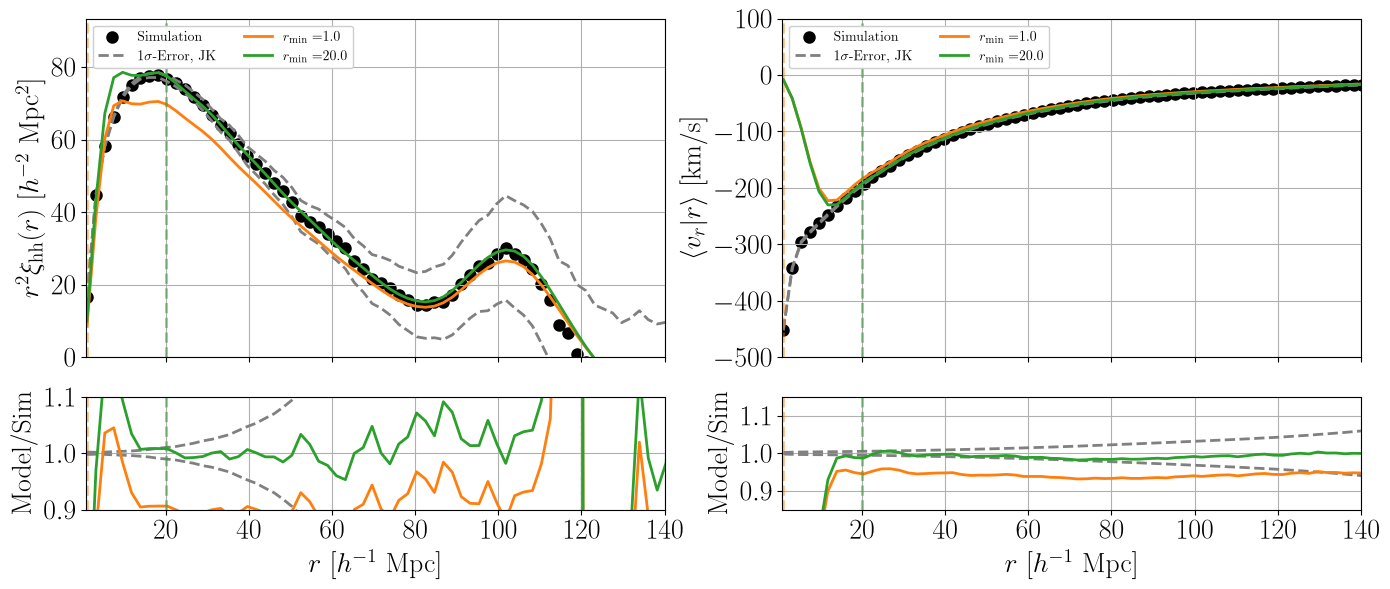

In [41]:
rmins = [1, 20]
plot_joint_fits(rbins_c, 
                xi, 
                mom_dict['m10'][()], 
                np.diag(xi_cov), 
                np.ones(np.diag(xi_cov).shape), 
                pars_best_joint)

In [42]:
lpt_xi = xihh_real(rbins_c, pars_best_joint[1][:-2])
lpt_m10 = v12_real(rbins_c, pars_best_joint[1][:-2])

In [43]:
lpt_mean = UnivariateSpline(rbins_c, lpt_m10, s=0, k=5, ext=3)

lpt_compact = lambda v, rp, rl: (1/uc)*Pv_compact(v/uc, rp, rl, lpt_mean)

lpt_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     lpt_xi, s=0),
    los_pdf_function=lpt_compact,
    limit=160, 
    epsilon=0.01,
    #n=300,
)

lpt_monopole = tpcf_multipole(
    lpt_s_mu,
    mu_bins, 
    order=0
)
lpt_quadrupole = tpcf_multipole(
    lpt_s_mu, 
    mu_bins, 
    order=2
)
lpt_hexadecapole = tpcf_multipole(
    lpt_s_mu, 
    mu_bins, 
    order=4)

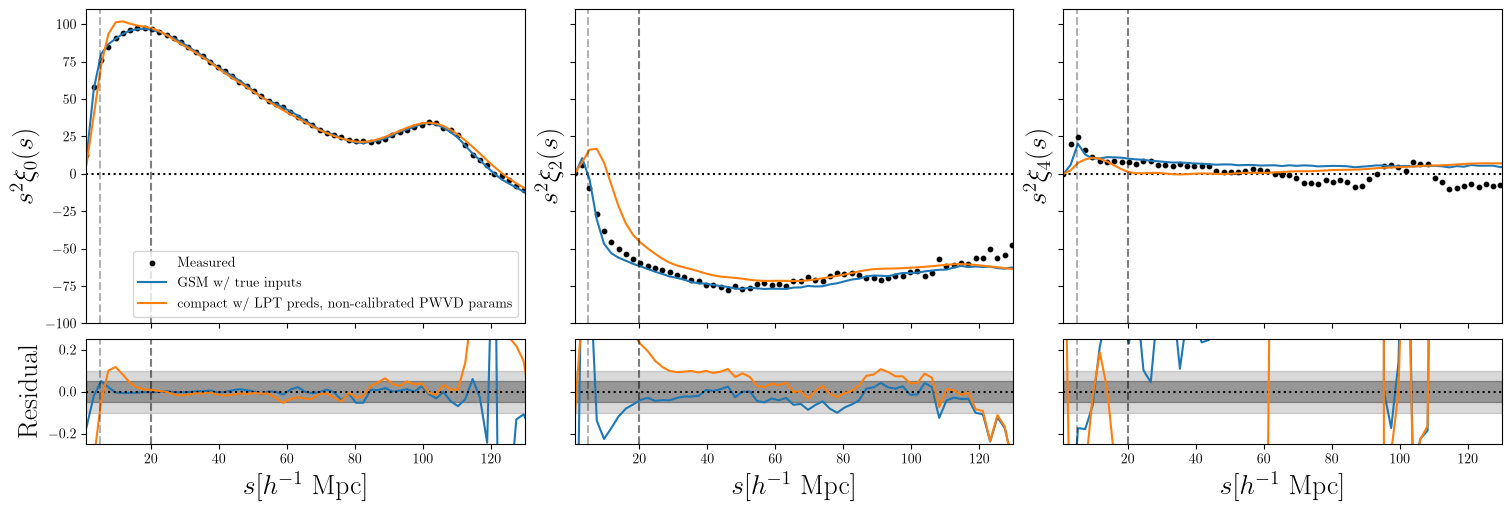

In [48]:
fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole], label='GSM w/ true inputs',)

lpt_multipoles = [lpt_monopole, lpt_quadrupole, lpt_hexadecapole]
multipoles = [monopole, quadrupole, hexadecapole]

for i, lm in enumerate(lpt_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*lm, label='compact w/ LPT preds, non-calibrated PWVD params', color='C1', ls='-')

    axes[1, i].plot(rbins_c, (lm-multipoles[i])/(np.abs(multipoles[i])+1e-8))

    axes[0, i].axvline(20, c='k', alpha=0.5, ls='--')
    axes[1, i].axvline(20, c='k', alpha=0.5, ls='--')

    axes[0, i].axvline(5, c='k', alpha=0.3, ls='--')
    axes[1, i].axvline(5, c='k', alpha=0.3, ls='--')

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 130))
axes[0, 1].set_xlim((1, 130))
axes[0, 2].set_xlim((1, 130))

axes[0, 0].legend()